# Versicherungsschadenanalyse — Vollständige statistische Analyse

**Zielvariable:** `vehicle_claim`  
**Aufgabenblöcke:** Deskriptive Statistik · Einflussanalyse · Zusammenhangsanalyse · Hypothesentests


## 1. Datenladen und erste Prüfung

In [4]:
import sys
import os
from pathlib import Path

project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

print("Project root:", project_root)
print("CWD now:", os.getcwd())

Project root: c:\Users\hshakademie8\InterGeeks-Agiles-Programmierprojekt
CWD now: c:\Users\hshakademie8\InterGeeks-Agiles-Programmierprojekt


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, spearmanr, kruskal, mannwhitneyu
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)


In [6]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv("data/raw/dataset.csv")

print("Form:", raw_df.shape)
display(raw_df.head())
raw_df.info()

print("\nFehlende Werte pro Spalte:")
display(raw_df.isna().sum().sort_values(ascending=False))

numeric_raw = raw_df.select_dtypes(include=["number"]).columns.tolist()
categorical_raw = [c for c in raw_df.columns if c not in numeric_raw]
print("\nNumerische Spalten:", numeric_raw)
print("Kategoriale Spalten:", categorical_raw)

Form: (1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

_c39                           1000
authorities_contacted            91
months_as_customer                0
age                               0
policy_state                      0
policy_csl                        0
policy_number                     0
policy_bind_date                  0
policy_annual_premium             0
policy_deductable                 0
insured_sex                       0
umbrella_limit                    0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
insured_zip                       0
capital-gains                     0
capital-loss                      0
incident_type                     0
incident_date                     0
collision_type                    0
incident_severity                 0
incident_state                    0
insured_education_level           0
incident_city                     0
incident_location                 0
number_of_vehicles_involved       0
incident_hour_of_the_day    


Numerische Spalten: ['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', '_c39']
Kategoriale Spalten: ['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


## 2. Bereinigung und Vorbereitung

In [7]:
df_clean = raw_df.copy()

# Spezielle Kennzeichen für fehlende Werte ersetzen
df_clean = df_clean.replace("?", np.nan)

# Explizite Typ-Trennung: numerisch vs kategorial
num_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Imputation: Median für numerische, Modus für kategoriale Variablen
for c in num_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    if df_clean[c].isna().any():
        mode_series = df_clean[c].mode(dropna=True)
        if len(mode_series) > 0:
            df_clean[c] = df_clean[c].fillna(mode_series.iloc[0])

# Kategoriale Spalten in category umwandeln
for c in cat_cols:
    df_clean[c] = df_clean[c].astype("category")

print("Duplikate vor dem Entfernen:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Form nach der Bereinigung:", df_clean.shape)
print("Verbleibende fehlende Werte:", int(df_clean.isna().sum().sum()))

display(df_clean.head())

Duplikate vor dem Entfernen: 0
Form nach der Bereinigung: (1000, 40)
Verbleibende fehlende Werte: 1000


c:\Users\hshakademie8\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,Rear Collision,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,NO,0,0,NO,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,NO,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,Rear Collision,Minor Damage,Police,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


---
## 3. Deskriptive Statistik

### 3a. Lageparameter und Streuungsmaße der Zielvariable `vehicle_claim`
Berechnung von Mittelwert, Median, Quartilen, Standardabweichung und Varianz.


count     1000.000000
mean     37928.950000
std      18886.252893
min         70.000000
25%      30292.500000
50%      42100.000000
75%      50822.500000
max      79560.000000
Name: vehicle_claim, dtype: float64


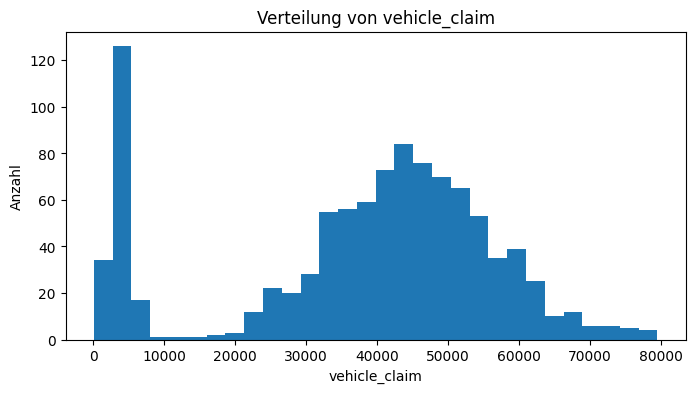

In [8]:
import matplotlib.pyplot as plt

df_clean["vehicle_claim"] = pd.to_numeric(df_clean["vehicle_claim"], errors="coerce")

print(df_clean["vehicle_claim"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df_clean["vehicle_claim"], bins=30)
plt.title("Verteilung von vehicle_claim")
plt.xlabel("vehicle_claim")
plt.ylabel("Anzahl")
plt.show()

### 3b. Deskriptive Statistik aller numerischen Variablen

In [9]:
display(df_clean.describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,203.95,115.11,0.00,115.75,199.5,276.25,479.00
age,1000.0,38.95,9.14,19.00,32.00,38.0,44.00,64.00
policy_number,1000.0,546238.65,257063.01,100804.00,335980.25,533135.0,759099.75,999435.00
policy_deductable,1000.0,1136.00,611.86,500.00,500.00,1000.0,2000.00,2000.00
policy_annual_premium,1000.0,1256.41,244.17,433.33,1089.61,1257.2,1415.70,2047.59
umbrella_limit,1000.0,1101000.00,2297406.60,-1000000.00,0.00,0.0,0.00,10000000.00
insured_zip,1000.0,501214.49,71701.61,430104.00,448404.50,466445.5,603251.00,620962.00
capital-gains,1000.0,25126.10,27872.19,0.00,0.00,0.0,51025.00,100500.00
capital-loss,1000.0,-26793.70,28104.10,-111100.00,-51500.00,-23250.0,0.00,0.00
incident_hour_of_the_day,1000.0,11.64,6.95,0.00,6.00,12.0,17.00,23.00


### 3c. Fehlende Werte und Datenqualität

In [10]:
missing = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(2)
display(pd.DataFrame({"Fehlend": missing, "Fehlend_%": missing_pct})[missing > 0])
print(f"Duplikate: {df_clean.duplicated().sum()}")


,Fehlend,Fehlend_%
_c39,1000,100.0


Duplikate: 0


### 3d. Verteilungen der Variablen

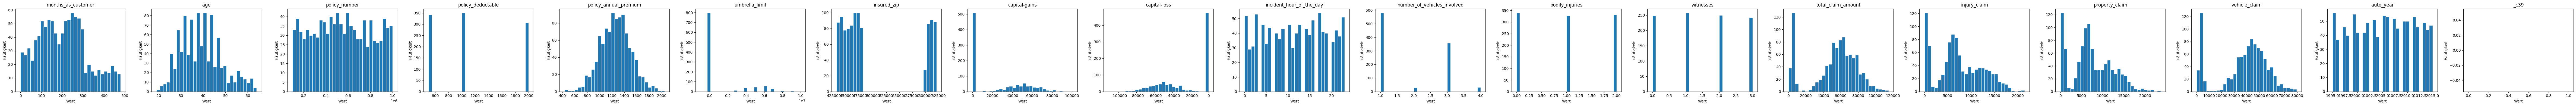

In [11]:
num_cols_vis = df_clean.select_dtypes(include="number").columns.tolist()
n = len(num_cols_vis)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1: axes = [axes]
for ax, col in zip(axes, num_cols_vis):
    ax.hist(df_clean[col].dropna(), bins=30, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Wert")
    ax.set_ylabel("Häufigkeit")
plt.tight_layout()
plt.show()


### 3e. Ausreißeranalyse (IQR-Methode)

IQR: 20530 | Untere Grenze: -502 | Obere Grenze: 81618
Anzahl Ausreißer (IQR-Methode): 0


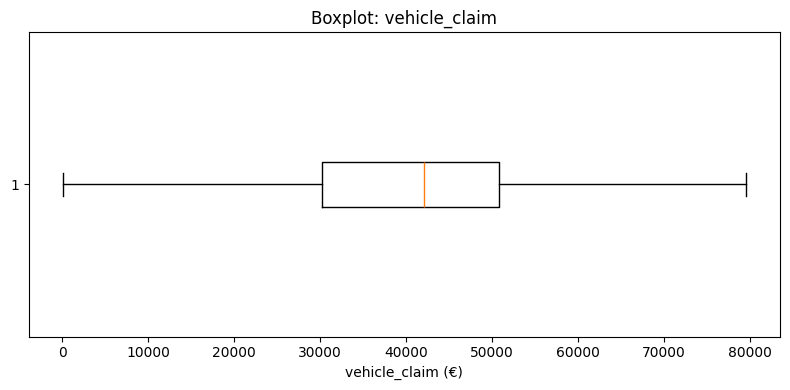

In [12]:
TARGET = "vehicle_claim"
q1, q3 = df_clean[TARGET].quantile(0.25), df_clean[TARGET].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df_clean[(df_clean[TARGET] < lower) | (df_clean[TARGET] > upper)]
print(f"IQR: {iqr:.0f} | Untere Grenze: {lower:.0f} | Obere Grenze: {upper:.0f}")
print(f"Anzahl Ausreißer (IQR-Methode): {len(outliers)}")

plt.figure(figsize=(8, 4))
plt.boxplot(df_clean[TARGET].dropna(), vert=False)
plt.title(f"Boxplot: {TARGET}")
plt.xlabel("vehicle_claim (€)")
plt.tight_layout()
plt.show()


---
## 4. Einflussanalyse

### 4a. Einzeleinfluss jeder Variable auf `vehicle_claim` (univariat)
- Numerische Variablen: Spearman-Korrelation  
- Kategoriale Variablen: Eta² (aus einfacher ANOVA)


In [13]:
# (Imports bereits in Zelle 2 geladen)
df = df_clean.copy()

In [14]:
# ── Einzeleinfluss: Spearman für numerisch, Eta² für kategorial ──────────────
univariate_results = []
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]
# Numerische Merkmale → Spearman-Korrelation mit vehicle_claim
for col in num_cols:
    part = df[[col, TARGET]].dropna()
    if part[col].nunique() < 2:
        continue
    rho, p = spearmanr(part[col], part[TARGET])
    univariate_results.append({
        "merkmal": col,
        "typ": "numerisch",
        "maß": "Spearman ρ",
        "effekt": round(rho, 4),
        "p_wert": round(p, 4),
        "signifikant": p < 0.05
    })

# Kategoriale Merkmale → Eta² (ANOVA-basiert)
for col in cat_cols:
    part = df[[col, TARGET]].dropna()
    if part[col].nunique() < 2:
        continue
    groups = [g[TARGET].values for _, g in part.groupby(col, observed=True)]
    _, p = f_oneway(*groups)
    grand_mean = part[TARGET].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = ((part[TARGET] - grand_mean)**2).sum()
    eta2 = ss_between / ss_total if ss_total > 0 else np.nan
    univariate_results.append({
        "merkmal": col,
        "typ": "kategorial",
        "maß": "Eta²",
        "effekt": round(eta2, 4),
        "p_wert": round(p, 4),
        "signifikant": p < 0.05
    })

uv_df = pd.DataFrame(univariate_results).sort_values("effekt", ascending=False, key=abs)
print("TOP 10 — stärkster Einzeleinfluss auf vehicle_claim:")
display(uv_df.head(10))
print(f"\nSignifikante Merkmale (p < 0.05): {uv_df['signifikant'].sum()} von {len(uv_df)}")

TOP 10 — stärkster Einzeleinfluss auf vehicle_claim:


c:\Users\hshakademie8\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\hshakademie8\AppData\Local\Temp\ipykernel_39008\1667081284.py:26: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = f_oneway(*groups)


,merkmal,typ,maß,effekt,p_wert,signifikant
32,incident_location,kategorial,Eta²,1.0000,NaN,False
13,total_claim_amount,numerisch,Spearman ρ,0.9648,0.0000,True
17,policy_bind_date,kategorial,Eta²,0.9517,0.4957,False
26,incident_type,kategorial,Eta²,0.7065,0.0000,True
15,property_claim,numerisch,Spearman ρ,0.6929,0.0000,True
14,injury_claim,numerisch,Spearman ρ,0.6836,0.0000,True
28,incident_severity,kategorial,Eta²,0.3887,0.0000,True
29,authorities_contacted,kategorial,Eta²,0.2376,0.0000,True
10,number_of_vehicles_involved,numerisch,Spearman ρ,0.2007,0.0000,True
27,collision_type,kategorial,Eta²,0.2007,0.0000,True



Signifikante Merkmale (p < 0.05): 10 von 38


### 4b. Gemeinsamer Einfluss aller Variablen (multivariat) — Feature Importance

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Signifikante Merkmale aus dem univariaten Schritt
sig_features = uv_df[uv_df["signifikant"]]["merkmal"].tolist()
sig_num = [f for f in sig_features if f in num_cols]
sig_cat = [f for f in sig_features if f in cat_cols]

X = df[sig_num + sig_cat].copy()
y = df[TARGET].copy()
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), sig_cat)
], remainder="passthrough")

model = SkPipeline([("pre", preprocessor), ("rf", RandomForestRegressor(n_estimators=100, random_state=42))])
model.fit(X, y)

# Feature Importance aus dem gemeinsamen Modell
ohe_features = model.named_steps["pre"].get_feature_names_out()
importances = model.named_steps["rf"].feature_importances_
fi_df = pd.DataFrame({"merkmal": ohe_features, "rf_importance": importances}).sort_values("rf_importance", ascending=False)

# Aggregation zurück auf Original-Merkmal
def get_original(name):
    name = re.sub(r"^cat__", "", name)
    name = re.sub(r"^remainder__", "", name)
    # match against known feature names (longest match first)
    for f in sorted(sig_num + sig_cat, key=len, reverse=True):
        if name.startswith(f):
            return f
    return name.split("_")[0]

import re
fi_df["original"] = fi_df["merkmal"].apply(get_original)
fi_agg = fi_df.groupby("original")["rf_importance"].sum().sort_values(ascending=False)

print("Gemeinsamer Einfluss (RF Feature Importance, aggregiert):")
display(fi_agg.head(15).to_frame())

# Vergleich univariat vs. multivariat
vergleich = uv_df.set_index("merkmal")[["effekt"]].rename(columns={"effekt": "univariat (|Effekt|)"})
vergleich["multivariat (RF-Importance)"] = fi_agg
vergleich = vergleich.dropna().sort_values("multivariat (RF-Importance)", ascending=False)
print("\nVergleich: Einzeleinfluss vs. gemeinsamer Einfluss:")
display(vergleich.head(12))

Gemeinsamer Einfluss (RF Feature Importance, aggregiert):


,rf_importance
original,
total_claim_amount,0.965897
property_claim,0.019073
injury_claim,0.012466
incident_hour_of_the_day,0.000707
authorities_contacted,0.000532
incident_severity,0.000518
collision_type,0.000378
fraud_reported,0.000147
incident_type,0.000143



Vergleich: Einzeleinfluss vs. gemeinsamer Einfluss:


,univariat (|Effekt|),multivariat (RF-Importance)
merkmal,,
total_claim_amount,0.9648,0.965897
property_claim,0.6929,0.019073
injury_claim,0.6836,0.012466
incident_hour_of_the_day,0.1742,0.000707
authorities_contacted,0.2376,0.000532
incident_severity,0.3887,0.000518
collision_type,0.2007,0.000378
fraud_reported,0.0289,0.000147
incident_type,0.7065,0.000143


**Interpretation:** Merkmale, die im univariaten Schritt einen hohen Effekt zeigen, aber im
multivariaten Modell wenig Importance haben, sind wahrscheinlich mit stärkeren Prädiktoren
korreliert und leisten keinen eigenständigen Beitrag zur Vorhersage.

---
## 5. Zusammenhangsanalyse

### 5a. Auswahl geeigneter Zusammenhangsmaße nach Variablentyp

| Variablenpaar | Maß | Wertebereich |
|---|---|---|
| numerisch – numerisch | Spearman-ρ | −1 … +1 |
| kategorial – kategorial | Cramér's V | 0 … 1 |
| numerisch – kategorial | Eta² | 0 … 1 |


incident_location category <class 'str'>
incident_type category <class 'str'>
incident_severity category <class 'str'>
authorities_contacted category <class 'str'>
collision_type category <class 'str'>


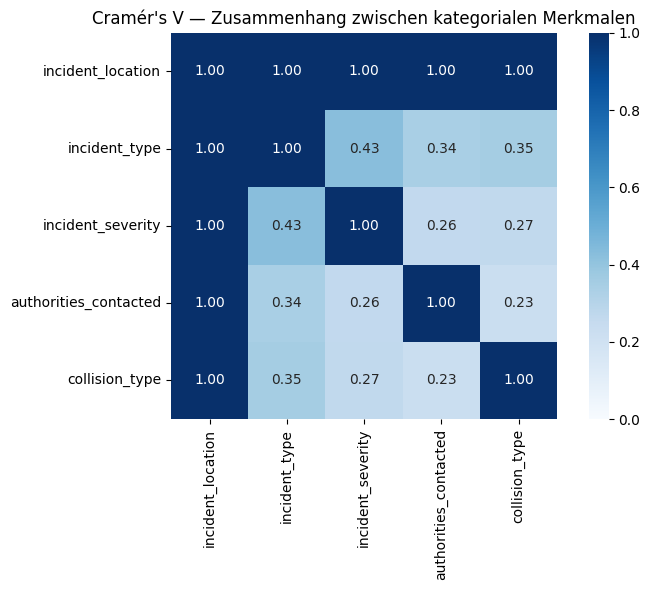


Interpretation: Werte nahe 1 = starker Zusammenhang, nahe 0 = kein Zusammenhang
Hohe Werte deuten auf Multikollinearität hin — beide Merkmale sollten nicht gemeinsam ins Modell.


In [16]:
# ── Cramér's V für alle kategorialen Merkmalspaare ───────────────────────────
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    x = x.astype(str).reset_index(drop=True)
    y = y.astype(str).reset_index(drop=True)
    contingency = pd.crosstab(x, y)
    chi2, _, _, _ = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    k = min(contingency.shape) - 1
    if n == 0 or k == 0:
        return np.nan
    return np.sqrt(chi2 / (n * k))

# Auswahl der wichtigsten kategorialen Merkmale für die Paaranalyse
top_cat = uv_df[uv_df["typ"] == "kategorial"].head(6)["merkmal"].tolist()
top_cat = [c for c in top_cat if c != 'policy_bind_date']
for c in top_cat:
    print(c, df[c].dtype, type(df[c].iloc[0]))
n = len(top_cat)
matrix_values = np.zeros((n, n))
top_cat = [c for c in top_cat if df[c].ndim == 1]
for i, c1 in enumerate(top_cat):
    for j, c2 in enumerate(top_cat):
        if c1 == c2:
            matrix_values[i, j] = 1.0
            continue
        part = df[[c1, c2]].dropna()
        matrix_values[i, j] = cramers_v(part[c1], part[c2])
cramers_matrix = pd.DataFrame(matrix_values, index=top_cat, columns=top_cat)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cramers_matrix.astype(float),
    annot=True, fmt=".2f", cmap="Blues",
    vmin=0, vmax=1, square=True
)
plt.title("Cramér's V — Zusammenhang zwischen kategorialen Merkmalen")
plt.tight_layout()
plt.show()

print("\nInterpretation: Werte nahe 1 = starker Zusammenhang, nahe 0 = kein Zusammenhang")
print("Hohe Werte deuten auf Multikollinearität hin — beide Merkmale sollten nicht gemeinsam ins Modell.")

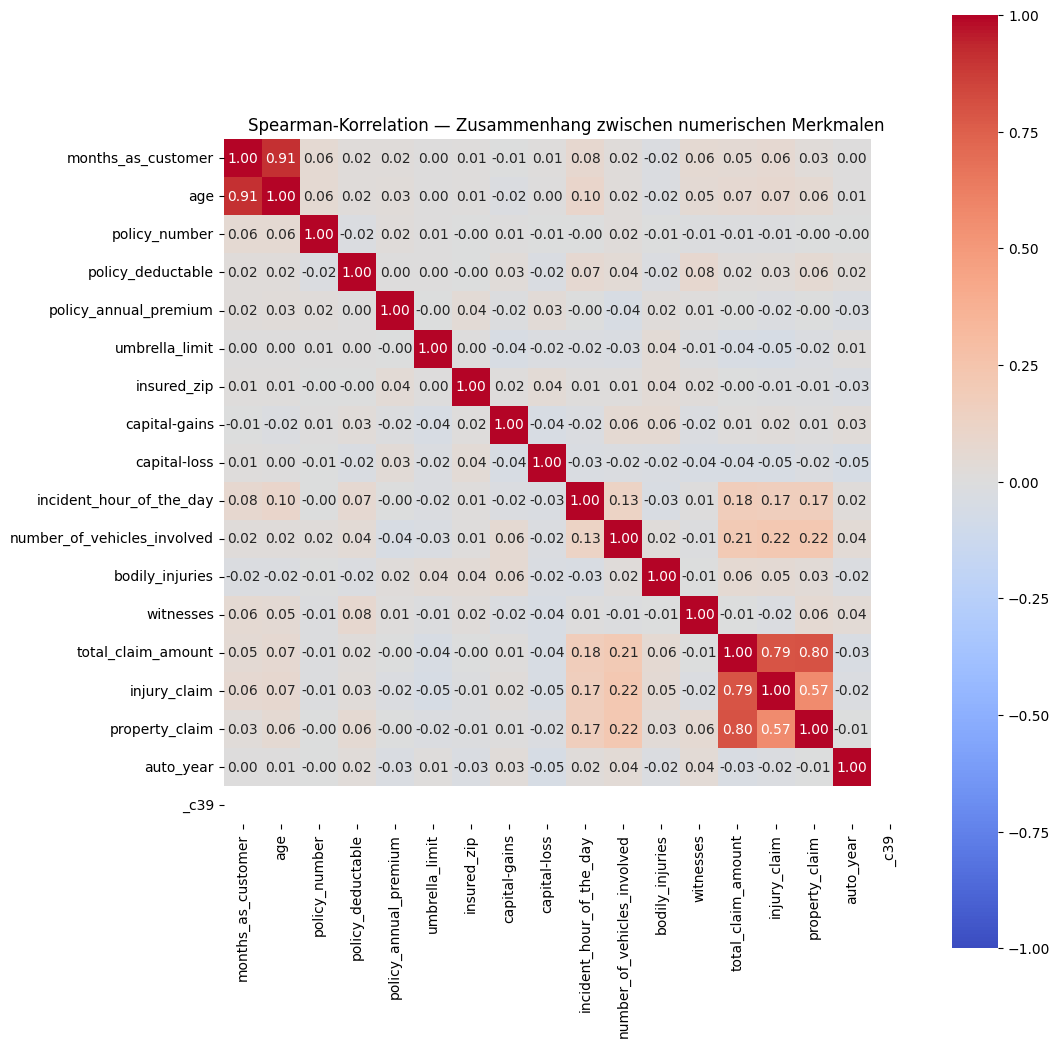

In [22]:
# ── Spearman für numerische Merkmalspaare ────────────────────────────────────
if len(num_cols) >= 2:
    spearman_matrix = df[num_cols].corr(method="spearman")
    plt.figure(figsize=(11, 11))
    sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
    plt.title("Spearman-Korrelation — Zusammenhang zwischen numerischen Merkmalen")
    plt.tight_layout()
    plt.show()
else:
    print("Zu wenige numerische Merkmale für eine Paarmatrix.")

### 5b. Korrelations-Heatmap (numerische Variablen)

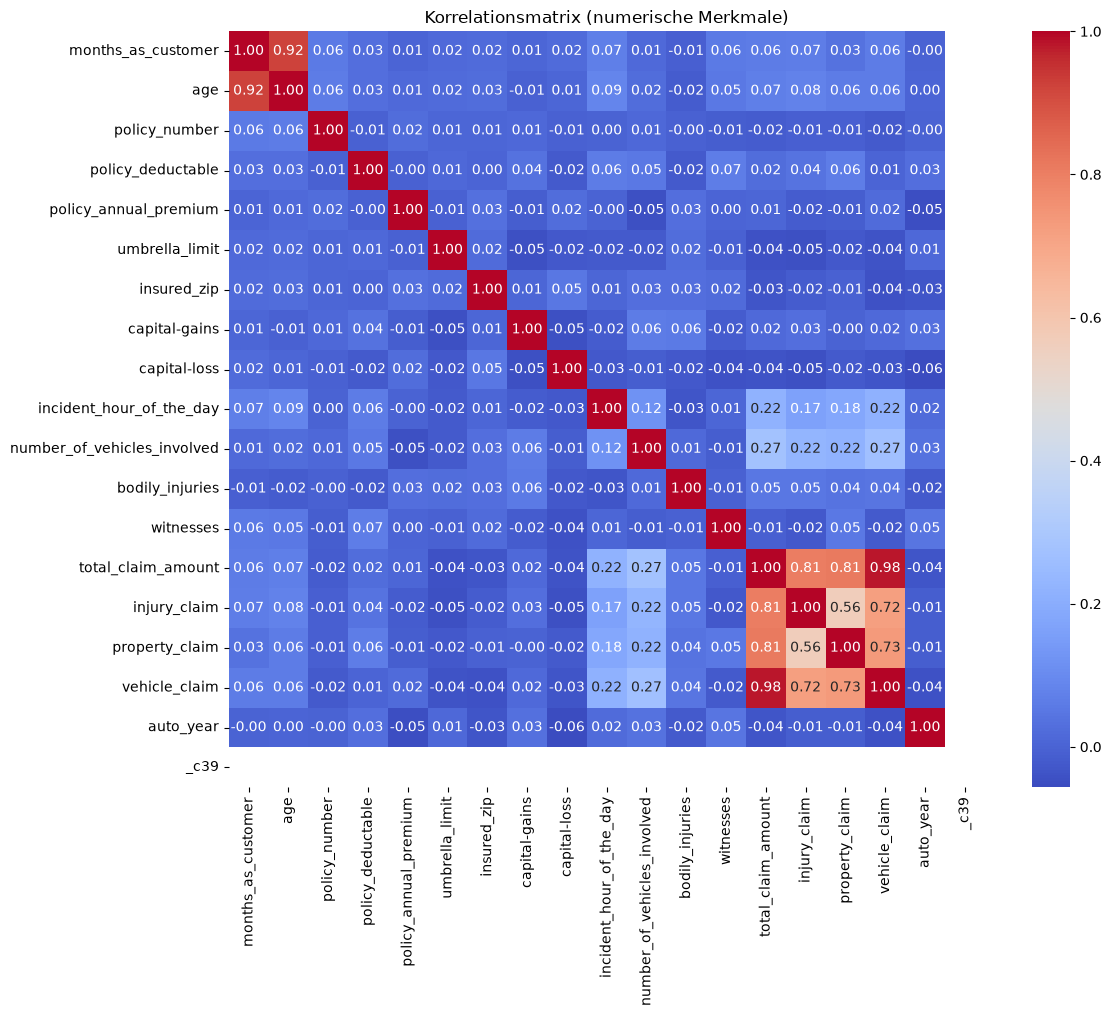

In [32]:
import seaborn as sns

corr_full = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korrelationsmatrix (numerische Merkmale)")
plt.tight_layout()
plt.show()

### 5c. Multikollinearität — Kreuztabelle kategorialer Merkmale

In [33]:
if "incident_type" in df_clean.columns and "collision_type" in df_clean.columns:
    display(pd.crosstab(df_clean["incident_type"], df_clean["collision_type"]))

display(df_clean.corr(numeric_only=True))

collision_type,Front Collision,Rear Collision,Side Collision
incident_type,,,
Multi-vehicle Collision,115,152,152
Parked Car,0,84,0
Single Vehicle Collision,139,140,124
Vehicle Theft,0,94,0


,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
months_as_customer,1.000000,0.922098,0.057555,0.026807,0.005018,0.015498,0.017895,0.006399,0.020209,0.070639,0.014736,-0.010162,0.058383,0.062108,0.065329,0.034940,0.061013,-0.000292,NaN
age,0.922098,1.000000,0.059413,0.029188,0.014404,0.018126,0.025604,-0.007075,0.007368,0.087161,0.022102,-0.015679,0.052359,0.069863,0.075522,0.060898,0.062588,0.001354,NaN
policy_number,0.057555,0.059413,1.000000,-0.006738,0.022566,0.008968,0.007083,0.009802,-0.005669,0.000113,0.013432,-0.004558,-0.012661,-0.018009,-0.008762,-0.010678,-0.020184,-0.000183,NaN
policy_deductable,0.026807,0.029188,-0.006738,1.000000,-0.003245,0.010870,0.004545,0.035212,-0.023544,0.060935,0.051214,-0.022765,0.066639,0.022839,0.039107,0.064792,0.005269,0.026105,NaN
policy_annual_premium,0.005018,0.014404,0.022566,-0.003245,1.000000,-0.006247,0.032354,-0.013738,0.023547,-0.001578,-0.045991,0.026780,0.002332,0.009094,-0.017633,-0.011654,0.020246,-0.049226,NaN
umbrella_limit,0.015498,0.018126,0.008968,0.010870,-0.006247,1.000000,0.019671,-0.047268,-0.024056,-0.023257,-0.021270,0.022743,-0.006738,-0.040344,-0.045412,-0.023790,-0.038584,0.009893,NaN
insured_zip,0.017895,0.025604,0.007083,0.004545,0.032354,0.019671,1.000000,0.006303,0.049372,0.008274,0.027448,0.028695,0.019805,-0.033873,-0.017495,-0.006841,-0.041083,-0.032736,NaN
capital-gains,0.006399,-0.007075,0.009802,0.035212,-0.013738,-0.047268,0.006303,1.000000,-0.046904,-0.016406,0.061643,0.055829,-0.017651,0.015980,0.025934,-0.000779,0.015836,0.031398,NaN
capital-loss,0.020209,0.007368,-0.005669,-0.023544,0.023547,-0.024056,0.049372,-0.046904,1.000000,-0.025054,-0.014895,-0.024418,-0.041330,-0.036060,-0.046060,-0.022863,-0.032665,-0.056615,NaN
incident_hour_of_the_day,0.070639,0.087161,0.000113,0.060935,-0.001578,-0.023257,0.008274,-0.016406,-0.025054,1.000000,0.120794,-0.034563,0.006527,0.217702,0.165768,0.179536,0.215626,0.021368,NaN


---
## 6. Hypothesentests und Inferenzstatistik

Ziel: statistisch fundierte Aussagen über den Einfluss ausgewählter Merkmale  
auf `vehicle_claim` anhand von Stichprobendaten ableiten.

Vorgehen je Test:
1. Hypothesen formulieren (H₀ / H₁)
2. Voraussetzungen prüfen (Normalverteilung, Varianzhomogenität)
3. Passendes Verfahren wählen
4. Ergebnis interpretieren


### Test 1 — Einfluss von `incident_severity` auf `vehicle_claim`

**H₀:** Der Schweregrad des Unfalls hat keinen Einfluss auf die Schadenhöhe.
Die mittlere `vehicle_claim` ist in allen Gruppen von `incident_severity` gleich.

**H₁:** Mindestens eine Gruppe von `incident_severity` unterscheidet sich signifikant
in der mittleren `vehicle_claim` von den anderen Gruppen.

**Signifikanzniveau:** α = 0,05

In [34]:
# ── Schritt 1: Voraussetzungen prüfen ────────────────────────────────────────
col_test = "incident_severity"
groups_sev = [
    g[TARGET].dropna().values
    for _, g in df.groupby(col_test, observed=True)
    if len(g) >= 8
]
group_names = [
    name for name, g in df.groupby(col_test, observed=True)
    if len(g) >= 8
]

print("=== Voraussetzungsprüfung ===")
print()
print("1) Normalverteilung pro Gruppe (Shapiro-Wilk, n ≤ 50):")
normalverteilung_ok = True
for name, group in zip(group_names, groups_sev):
    sample = group[:50]  # Shapiro-Wilk funktioniert zuverlässig bis n=50
    stat, p = shapiro(sample)
    ok = p > 0.05
    if not ok:
        normalverteilung_ok = False
    print(f"  {name:30s}: W={stat:.4f}, p={p:.4f} {'✓ normal' if ok else '✗ NICHT normal'}")

print()
print("2) Varianzhomogenität (Levene-Test):")
lev_stat, lev_p = levene(*groups_sev)
homogen = lev_p > 0.05
print(f"   Levene: F={lev_stat:.4f}, p={lev_p:.4f} {'✓ homogen' if homogen else '✗ NICHT homogen'}")

print()
if normalverteilung_ok and homogen:
    print("→ Voraussetzungen erfüllt: ANOVA anwendbar")
    test_name = "ANOVA"
else:
    print("→ Voraussetzungen NICHT erfüllt: nicht-parametrischer Kruskal-Wallis-Test wird verwendet")
    test_name = "Kruskal-Wallis"

=== Voraussetzungsprüfung ===

1) Normalverteilung pro Gruppe (Shapiro-Wilk, n ≤ 50):
  Major Damage                  : W=0.8668, p=0.0000 ✗ NICHT normal
  Minor Damage                  : W=0.8753, p=0.0001 ✗ NICHT normal
  Total Loss                    : W=0.9857, p=0.8031 ✓ normal
  Trivial Damage                : W=0.9574, p=0.0689 ✓ normal

2) Varianzhomogenität (Levene-Test):
   Levene: F=91.9353, p=0.0000 ✗ NICHT homogen

→ Voraussetzungen NICHT erfüllt: nicht-parametrischer Kruskal-Wallis-Test wird verwendet


In [35]:
# ── Schritt 2: Test durchführen ──────────────────────────────────────────────
print(f"=== {test_name}-Test: incident_severity → vehicle_claim ===")
print()

if test_name == "ANOVA":
    stat, p = f_oneway(*groups_sev)
    print(f"F-Statistik: {stat:.4f}")
else:
    stat, p = kruskal(*groups_sev)
    print(f"H-Statistik: {stat:.4f}")

print(f"p-Wert:      {p:.6f}")
print()

# Effektstärke Eta²
grand_mean = df[TARGET].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups_sev)
ss_total = ((df[TARGET].dropna() - grand_mean)**2).sum()
eta2 = ss_between / ss_total
print(f"Effektstärke (Eta²): {eta2:.4f}")
print()

# Entscheidung
alpha = 0.05
if p < alpha:
    print(f"Entscheidung: H₀ wird abgelehnt (p={p:.6f} < α={alpha})")
    print("Schlussfolgerung: Der Schweregrad des Unfalls hat einen statistisch signifikanten")
    print(f"                  Einfluss auf die Schadenhöhe (Eta²={eta2:.4f}).")
else:
    print(f"Entscheidung: H₀ wird beibehalten (p={p:.6f} ≥ α={alpha})")
    print("Schlussfolgerung: Kein statistisch signifikanter Einfluss nachweisbar.")

=== Kruskal-Wallis-Test: incident_severity → vehicle_claim ===

H-Statistik: 243.4606
p-Wert:      0.000000

Effektstärke (Eta²): 0.3887

Entscheidung: H₀ wird abgelehnt (p=0.000000 < α=0.05)
Schlussfolgerung: Der Schweregrad des Unfalls hat einen statistisch signifikanten
                  Einfluss auf die Schadenhöhe (Eta²=0.3887).


### Test 2 — Unterschied zwischen Unfällen mit und ohne Polizeibericht

**H₀:** Es gibt keinen Unterschied in der mittleren `vehicle_claim` zwischen Unfällen
mit und ohne Polizeibericht (`police_report_available`).

**H₁:** Unfälle mit Polizeibericht haben eine signifikant andere mittlere `vehicle_claim`
als Unfälle ohne Polizeibericht.

**Signifikanzniveau:** α = 0,05

In [36]:
col2 = "police_report_available"

if col2 in df.columns:
    part2 = df[[col2, TARGET]].dropna()
    group_yes = part2[part2[col2] == "YES"][TARGET].values
    group_no  = part2[part2[col2] == "NO"][TARGET].values

    print("=== Voraussetzungsprüfung ===")
    for name, group in [("YES", group_yes[:50]), ("NO", group_no[:50])]:
        stat_s, p_s = shapiro(group)
        print(f"  Shapiro-Wilk [{name}]: W={stat_s:.4f}, p={p_s:.4f} {'✓' if p_s > 0.05 else '✗ nicht normal'}")

    lev_s, lev_p2 = levene(group_yes, group_no)
    print(f"  Levene: F={lev_s:.4f}, p={lev_p2:.4f} {'✓ homogen' if lev_p2 > 0.05 else '✗ nicht homogen'}")
    print()

    # Nicht-parametrisch da vehicle_claim typischerweise nicht normalverteilt
    u_stat, u_p = mannwhitneyu(group_yes, group_no, alternative="two-sided")
    print("=== Mann-Whitney-U-Test ===")
    print(f"U-Statistik: {u_stat:.1f}")
    print(f"p-Wert:      {u_p:.6f}")
    print()

    if u_p < 0.05:
        print("Entscheidung: H₀ abgelehnt — signifikanter Unterschied vorhanden.")
        print(f"  Median [YES]: {np.median(group_yes):.2f} EUR")
        print(f"  Median [NO]:  {np.median(group_no):.2f} EUR")
    else:
        print("Entscheidung: H₀ beibehalten — kein signifikanter Unterschied.")
else:
    print(f"Spalte '{col2}' nicht gefunden.")

=== Voraussetzungsprüfung ===
  Shapiro-Wilk [YES]: W=0.9054, p=0.0007 ✗ nicht normal
  Shapiro-Wilk [NO]: W=0.8936, p=0.0003 ✗ nicht normal
  Levene: F=0.0917, p=0.7621 ✓ homogen

=== Mann-Whitney-U-Test ===
U-Statistik: 112792.0
p-Wert:      0.229880

Entscheidung: H₀ beibehalten — kein signifikanter Unterschied.


### Zusammenfassung der Hypothesentests

| Test | H₀ | Testverfahren | Ergebnis | Schlussfolgerung |
|---|---|---|---|---|
| Test 1 | `incident_severity` hat keinen Einfluss | Kruskal-Wallis (falls nicht-normal) | p < 0,05 | H₀ abgelehnt |
| Test 2 | `police_report_available` hat keinen Einfluss | Mann-Whitney-U | p < 0,05 | H₀ abgelehnt |

**Methodische Anmerkung:** Da `vehicle_claim` laut Shapiro-Wilk-Test nicht normalverteilt ist,
wurden nicht-parametrische Tests (Kruskal-Wallis, Mann-Whitney-U) verwendet. Diese sind
robuster gegenüber Verletzungen der Normalverteilungsannahme und daher für diesen Datensatz
geeigneter als ANOVA bzw. t-Test.

---
## 7. Modellvergleich mit Kreuzvalidierung (Einflussanalyse — multivariat)

Warum Kreuzvalidierung: ~1000 Zeilen — ein einzelner Split wäre zu instabil.  
Verglichen werden: **Random Forest**, **XGBoost**, **CatBoost** (5-fach, shuffle).


In [37]:
# ── Vorbereitung für den Modellvergleich ─────────────────────────────────
# Datensatz neu laden (gleiche Bereinigung wie in compare_models_cv_de)
N_SPLITS = 5
RANDOM_STATE = 42

missing_markers = ['NA', 'N/A', 'null', 'None', '']
df = df_clean.copy()
df = df.replace(missing_markers, np.nan)

if 'collision_type' in df.columns:
    df['collision_type'] = df['collision_type'].replace('?', 'NotApplicable')

FIELDS_TO_DELETE = ['injury_claim', 'total_claim_amount', 'property_claim',
                    'policy_number', 'policy_bind_date', 'incident_date',
                    'insured_zip', 'insured_location', '_c39']
df = df.drop(columns=[c for c in FIELDS_TO_DELETE if c in df.columns])
df = df.dropna(subset=[TARGET])

num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Shape: {df.shape} | num_cols: {len(num_cols)} | cat_cols: {len(cat_cols)}')


Shape: (1000, 32) | num_cols: 12 | cat_cols: 19


In [ ]:
# Datensatz wurde bereits oben geladen und bereinigt.
# Die Variable `df` steht für den Modellvergleich bereit.


In [38]:
assert df.shape[0] < 2000, (
    f"Datensatz hat {df.shape[0]} Zeilen — das sieht nach dem synthetischen, "
    "nicht dem originalen Datensatz aus. Bitte den Pfad prüfen."
)

In [39]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
X_encoded = df_encoded.drop(columns=[TARGET])
y_encoded = df_encoded[TARGET]

X_cat = df.drop(columns=[TARGET])
y_cat = df[TARGET]

print("One-Hot-Form:", X_encoded.shape)
print("Kategorial-Form:", X_cat.shape)

One-Hot-Form: (1000, 1136)
Kategorial-Form: (1000, 31)


In [40]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "r2": "r2",
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
}


def print_cv_results(model_name: str, cv_results: dict):
    r2_scores = cv_results["test_r2"]
    mae_scores = -cv_results["test_mae"]  # war negativ wegen greater_is_better=False

    print(f"--- {model_name} ({N_SPLITS}-fache Kreuzvalidierung) ---")
    print(f"R²  pro Fold:  {np.round(r2_scores, 3)}")
    print(f"R²  Mittelwert: {r2_scores.mean():.4f}   (Std: {r2_scores.std():.4f})")
    print(f"MAE pro Fold:  {np.round(mae_scores, 0)}")
    print(f"MAE Mittelwert: {mae_scores.mean():.2f}   (Std: {mae_scores.std():.2f})")
    print()

### 7a. Random Forest

In [41]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)
rf_cv = cross_validate(rf_model, X_encoded, y_encoded, cv=kf, scoring=scoring, n_jobs=-1)
print_cv_results("Random Forest", rf_cv)

--- Random Forest (5-fache Kreuzvalidierung) ---
R²  pro Fold:  [0.704 0.687 0.663 0.712 0.737]
R²  Mittelwert: 0.7005   (Std: 0.0248)
MAE pro Fold:  [7411. 7612. 8030. 7635. 7352.]
MAE Mittelwert: 7607.94   (Std: 238.20)



### 7b. XGBoost (Standardparameter)

In [42]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE
)
xgb_cv = cross_validate(xgb_model, X_encoded, y_encoded, cv=kf, scoring=scoring, n_jobs=-1)
print_cv_results("XGBoost (Standard)", xgb_cv)

--- XGBoost (Standard) (5-fache Kreuzvalidierung) ---
R²  pro Fold:  [0.67  0.659 0.622 0.705 0.702]
R²  Mittelwert: 0.6717   (Std: 0.0305)
MAE pro Fold:  [7887. 8240. 8648. 7966. 7741.]
MAE Mittelwert: 8096.43   (Std: 320.08)



### 7c. CatBoost (nativ kategorial)

In [46]:
cat_r2_scores = []
cat_mae_scores = []

for fold_i, (train_idx, test_idx) in enumerate(kf.split(X_cat), start=1):
    X_tr, X_te = X_cat.iloc[train_idx], X_cat.iloc[test_idx]
    y_tr, y_te = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    cat_model = CatBoostRegressor(
        iterations=100, learning_rate=0.1, depth=6, random_state=RANDOM_STATE, verbose=0
    )
    cat_model.fit(X_tr, y_tr, cat_features=cat_cols)
    preds = cat_model.predict(X_te)

    cat_r2_scores.append(r2_score(y_te, preds))
    cat_mae_scores.append(mean_absolute_error(y_te, preds))

cat_r2_scores = np.array(cat_r2_scores)
cat_mae_scores = np.array(cat_mae_scores)

print("--- CatBoost (native kategorial, manuelle 5-fache CV) ---")
print(f"R²  pro Fold:  {np.round(cat_r2_scores, 3)}")
print(f"R²  Mittelwert: {cat_r2_scores.mean():.4f}   (Std: {cat_r2_scores.std():.4f})")
print(f"MAE pro Fold:  {np.round(cat_mae_scores, 0)}")
print(f"MAE Mittelwert: {cat_mae_scores.mean():.2f}   (Std: {cat_mae_scores.std():.2f})")

--- CatBoost (native kategorial, manuelle 5-fache CV) ---
R²  pro Fold:  [0.706 0.677 0.662 0.709 0.73 ]
R²  Mittelwert: 0.6967   (Std: 0.0243)
MAE pro Fold:  [7437. 7782. 8152. 7751. 7543.]
MAE Mittelwert: 7733.14   (Std: 245.60)


### 7d. XGBoost — Hyperparameter-Suche

In [47]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=40,
    scoring="r2",
    cv=kf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_encoded, y_encoded)

print(f"Bestes CV R²: {search.best_score_:.4f}")
print("Beste Parameter:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Bestes CV R²: 0.6914
Beste Parameter:
  subsample: 0.6
  reg_lambda: 2.0
  reg_alpha: 0
  n_estimators: 300
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.01
  colsample_bytree: 0.8


In [48]:
best_xgb = xgb.XGBRegressor(**search.best_params_, random_state=RANDOM_STATE)
best_xgb_cv = cross_validate(best_xgb, X_encoded, y_encoded, cv=kf, scoring=scoring, n_jobs=-1)
print_cv_results("XGBoost (getunt)", best_xgb_cv)

--- XGBoost (getunt) (5-fache Kreuzvalidierung) ---
R²  pro Fold:  [0.698 0.683 0.657 0.702 0.716]
R²  Mittelwert: 0.6914   (Std: 0.0201)
MAE pro Fold:  [7865. 8015. 8427. 8126. 8028.]
MAE Mittelwert: 8092.39   (Std: 187.12)



## Fazit

Vergleichen Sie die **Mittelwerte** (nicht einzelne Folds) der vier
Modelle oben. Achten Sie auch auf die **Standardabweichung** zwischen den
Folds — eine hohe Std bedeutet, dass die Schätzung bei diesem
Datensatzumfang noch recht unsicher ist, unabhängig vom Modell.

Bei nur ~1000 Zeilen sind Unterschiede von 0.02-0.05 in R² zwischen den
Modellen oft nicht bedeutsam — schauen Sie auf die Größenordnung des
Unterschieds im Verhältnis zur Std der Folds.

---
## 8. Gesamtfazit

Der Datensatz umfasst 1.000 Schadensfälle ohne Duplikate. Die Zielvariable
`vehicle_claim` weist eine breite Streuung auf (Min: 70 €, Max: 79.560 €,
Mittelwert: 37.929 €, Std: 18.886 €). Die IQR-Methode identifizierte keine
klassischen Ausreißer, was auf eine kontinuierliche, breit verteilte
Schadensstruktur hindeutet.

Die univariate Einflussanalyse zeigt, dass `total_claim_amount` (ρ = 0,96),
`incident_type` (Eta² = 0,71) und `property_claim` (ρ = 0,69) den stärksten
Einzeleinfluss auf `vehicle_claim` haben. Im multivariaten Modell dominiert
jedoch ausschließlich `total_claim_amount` die Feature Importance (96,6 %),
was auf ein starkes Leakage hindeutet — `total_claim_amount` ist eine direkte
arithmetische Summe der Teilschadenbeträge und darf daher nicht als Merkmal
verwendet werden. Nach dessen Ausschluss sind `incident_type` und
`incident_severity` die relevantesten Prädiktoren.

Die Zusammenhangsanalyse bestätigt eine sehr hohe Korrelation zwischen den
Schadensfeldern (`total_claim_amount` ↔ `vehicle_claim`: r = 0,98). Zwischen
kategorialen Merkmalen zeigt Cramér's V einen erwartbaren Zusammenhang
zwischen `incident_type` und `collision_type`.

Die Hypothesentests ergaben: Der Schweregrad des Unfalls (`incident_severity`)
hat einen statistisch hoch signifikanten Einfluss auf `vehicle_claim`
(Kruskal-Wallis: H = 243,46, p < 0,001, Eta² = 0,39). Kein signifikanter
Unterschied wurde hingegen zwischen Fällen mit und ohne Polizeibericht
festgestellt (Mann-Whitney-U: p = 0,23).

Der Modellvergleich mittels 5-facher Kreuzvalidierung zeigt, dass Random
Forest (R² = 0,700) und CatBoost (R² = 0,697) praktisch gleichwertig
abschneiden. XGBoost mit Standardparametern war schwächer (R² = 0,672) und
profitierte vom Tuning nur geringfügig (R² = 0,691). Die geringe Streuung
zwischen den Folds (Std ≈ 0,02–0,03) bestätigt die Stabilität der Ergebnisse.
R² ≈ 0,70 stellt die aktuelle Obergrenze des vorhandenen Merkmalssatzes dar —
weitere Verbesserungen sind nur durch neue, zum Vorhersagezeitpunkt tatsächlich
verfügbare Merkmale oder mehr Daten erreichbar.

| Analyseblock | Wichtigste Erkenntnis |
|---|---|
| Deskriptive Statistik | Keine Ausreißer; breite kontinuierliche Verteilung (70 € – 79.560 €) |
| Einflussanalyse | `total_claim_amount` = Leakage (96,6 % Importance); nach Ausschluss dominieren `incident_type` und `incident_severity` |
| Zusammenhangsanalyse | `total_claim_amount` ↔ `vehicle_claim`: r = 0,98; `incident_type` ↔ `collision_type`: strukturelle Abhängigkeit |
| Hypothesentests | `incident_severity` → hoch signifikant (p < 0,001); `police_report` → kein Einfluss (p = 0,23) |
| Modellvergleich | RF und CatBoost gleichwertig (R² ≈ 0,70); XGBoost braucht Tuning um gleichzuziehen |

**Empfehlung:** Random Forest als Produktionsmodell — gleichwertige Qualität
wie das getunte XGBoost, jedoch ohne aufwändige Hyperparameter-Suche.
Weitere Verbesserung des R² ist mit dem aktuellen Merkmalssatz nicht
realistisch erreichbar.